In [6]:
import numpy as np
import pandas as pd
import pickle as pk
# import seaborn as sns
import os, sys, re, operator 
from functools import reduce
from itertools import product
import matplotlib.patches as patches
from scipy.optimize import curve_fit as cfit
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

from util import *
# sys.path.insert(0, '../../scripts_analysis')
# from misc import *
# from peaks import *
# from analysis import *

plt.style.use('dark_background')
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.family'] = 'Noto Sans'

simTypes = ['control_eachCa']

dataPath = "../data"
resultPath = "/media/nishant/1tb/"
figPath = "../plots/Ca_dynamics"


x0 = 0   #nm
y0 = 0    #nm
xs = 250   #nm
az_x = 500 #nm
az_y = 400 #nm
azpos = {
    '1':  [x0,           y0       ],
    '2':  [x0-az_x,      y0       ],
    '3':  [x0+az_x,      y0       ],
    '4':  [x0-xs,        y0-az_y  ],
    '5':  [x0+xs,        y0+az_y  ],
    '6':  [x0-xs,        y0+az_y  ],
    '7':  [x0+xs,        y0-az_y  ],
    '8':  [x0-2*az_x,    y0       ],
    '9':  [x0+2*az_x,    y0       ],
    '10': [x0-az_x-xs,   y0-az_y  ],
    '11': [x0+az_x+xs,   y0+az_y  ],
    '12': [x0+az_x+xs,   y0-az_y  ],
    '13': [x0-az_x-xs,   y0+az_y  ],
    '14': [x0,           y0-2*az_y],
    '15': [x0,           y0+2*az_y],
    '16': [x0-az_x,      y0-2*az_y],
    '17': [x0+az_x,      y0+2*az_y],
    '18': [x0-az_x,      y0+2*az_y],
    '19': [x0+az_x,      y0-2*az_y],
    '20': [x0-3*az_x,    y0       ],
    '21': [x0+3*az_x,    y0       ],
    '22': [x0-2*az_x-xs, y0-az_y  ],
    '23': [x0+2*az_x+xs, y0+az_y  ],
    '24': [x0-2*az_x-xs, y0+az_y  ],
    '25': [x0+2*az_x+xs, y0-az_y  ],
    '26': [x0-2*az_x,    y0-2*az_y],
    '27': [x0+2*az_x,    y0+2*az_y],
    '28': [x0-2*az_x,    y0+2*az_y],
    '29': [x0+2*az_x,    y0-2*az_y]
}

simType = simTypes[0]
dirs = [a for a in getDirs(os.path.join(resultPath, simType), sstr='nVDCC') if "ISI_20" in a]
dirs.sort(key=natural_keys)
dirs = np.array(dirs)[:]

for i,d in enumerate(dirs): print(i, d)

0 nVDCC_3_dVDCC_60_nAZ_7_RRP_20_ISI_20_nAP_10
1 nVDCC_3_dVDCC_60_nAZ_17_RRP_10_ISI_20_nAP_10
2 nVDCC_3_dVDCC_80_nAZ_27_RRP_35_ISI_20_nAP_10
3 nVDCC_4_dVDCC_60_nAZ_9_RRP_5_ISI_20_nAP_10
4 nVDCC_4_dVDCC_80_nAZ_17_RRP_35_ISI_20_nAP_10
5 nVDCC_4_dVDCC_80_nAZ_27_RRP_20_ISI_20_nAP_10
6 nVDCC_4_dVDCC_80_nAZ_29_RRP_15_ISI_20_nAP_10
7 nVDCC_7_dVDCC_80_nAZ_7_RRP_10_ISI_20_nAP_10
8 nVDCC_7_dVDCC_100_nAZ_7_RRP_30_ISI_20_nAP_10
9 nVDCC_7_dVDCC_100_nAZ_29_RRP_5_ISI_20_nAP_10
10 nVDCC_7_dVDCC_140_nAZ_27_RRP_15_ISI_20_nAP_10
11 nVDCC_7_dVDCC_160_nAZ_19_RRP_40_ISI_20_nAP_10
12 nVDCC_7_dVDCC_160_nAZ_27_RRP_20_ISI_20_nAP_10
13 nVDCC_8_dVDCC_100_nAZ_7_RRP_20_ISI_20_nAP_10
14 nVDCC_8_dVDCC_100_nAZ_19_RRP_5_ISI_20_nAP_10
15 nVDCC_8_dVDCC_140_nAZ_17_RRP_20_ISI_20_nAP_10
16 nVDCC_8_dVDCC_200_nAZ_29_RRP_20_ISI_20_nAP_10
17 nVDCC_8_dVDCC_220_nAZ_27_RRP_30_ISI_20_nAP_10
18 nVDCC_9_dVDCC_120_nAZ_9_RRP_20_ISI_20_nAP_10
19 nVDCC_9_dVDCC_140_nAZ_9_RRP_30_ISI_20_nAP_10
20 nVDCC_9_dVDCC_140_nAZ_19_RRP_10_ISI_20_nAP_10

## get AZ and VDCC loations in grid

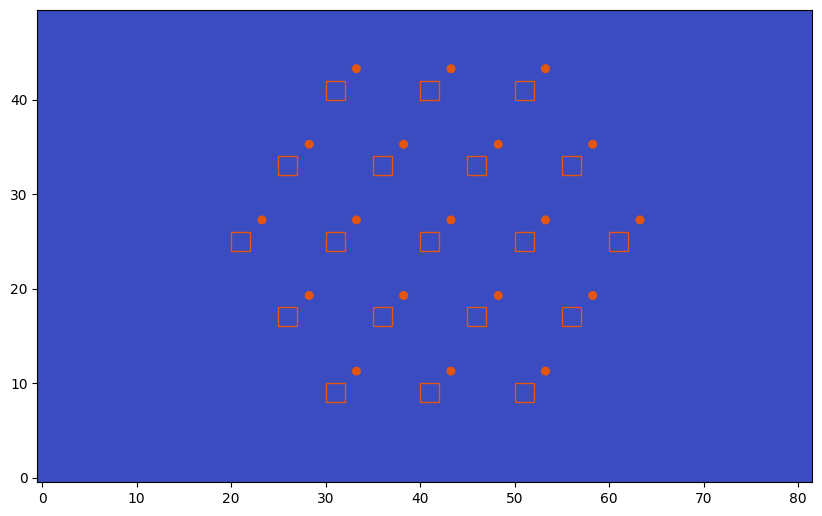

In [7]:
def getAZgrid(d, ssize, plot=False):
    azsize, e = 0.1, 1e-5 # um
    xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]
    gridLim = np.array([xlim[0]+e, ylim[0]+e])
    
    nAZ = int(getSimInfo(d, 'nAZ'))
    azp = np.array(list(azpos.values())[:nAZ])*1e-3
    
    dVDCC = int(getSimInfo(d, 'dVDCC'))
    shift = dVDCC*1e-3/np.sqrt(2)
    
    grid = (int(np.ceil((xlim[1] - xlim[0])/ssize)), 
            int(np.ceil((ylim[1] - ylim[0])/ssize)))
    azgrid = np.zeros(grid)
    
    xyaz =   np.array((azp - gridLim - azsize/2)/ssize)
    xyvdcc = np.array((azp - gridLim + [shift, shift])/ssize)
    #print(xyvdcc)
    
    if plot:
        f, ax = plt.subplots(figsize=(10,10))
        ax.imshow(azgrid.T, cmap='coolwarm')
        ax.invert_yaxis()
        
        for xy in xyaz:
            # AZ
            ax.add_patch(patches.Rectangle(xy, azsize/ssize, azsize/ssize, 
                                           edgecolor=cpdark[1], fill=False))
        for xy in xyvdcc:
            # VDCC Cluster
            ax.add_patch(patches.Circle(xy, 0.02/ssize, edgecolor=cpdark[1], 
                                        facecolor=cpdark[1], fill=True))
            
        #ax.grid()
        
    return xyaz, xyvdcc

azgrid = getAZgrid(dirs[11], 0.05, plot=True)

## Calcium extent of an active zone

In [ ]:
xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]
ssize = 0.02 # um
th = 4
for d in dirs[16:17]:
    caGridFiles = [a for a in os.listdir(os.path.join(resultPath, simType, d)) 
                   if 'caGrid' in a and f'step_{ssize:0.2f}' in a]
    caGridFiles.sort(key=natural_keys)
    caGridFiles = caGridFiles[:]
    #print(d,caGridFiles)
    
    nAP = len(caGridFiles)-1
    
    # AZ grid
    xyaz, xyvdcc = getAZgrid(d, ssize, plot=False)
    azsize = 0.1
    #print(xyAZ)
    
    f, ax = plt.subplots(nAP, figsize=(8,4*nAP), sharex=True)
    f.subplots_adjust(wspace=0.0, hspace=0.0)
    
    for i, caGridFile in enumerate(caGridFiles[1:]):
        with open(os.path.join(resultPath, simType, d, caGridFile), 'rb') as infile:
            cagrid = pk.load(infile, encoding="bytes")

        grid = cagrid[b'Ca1']
        gridth = np.argmax(grid<th, axis=2)*ssize*1000
        
        #ax[i].imshow(azgrid.T, cmap='binary')
        im = ax[i].imshow(gridth.T, vmin=0, vmax=300, cmap='coolwarm')
        
        for xy in xyaz: # Active Zones
            ax[i].add_patch(patches.Rectangle(xy, azsize/ssize, azsize/ssize, edgecolor='black', lw=2, fill=False))
            
        for xy in xyvdcc: # VDCC Cluster
            ax[i].add_patch(patches.Circle(xy, 0.02/ssize, edgecolor='black', facecolor='black', fill=True))
        
        ax[i].invert_yaxis()
    f.colorbar(im, ax=ax.ravel().tolist(), shrink=0.5)

## Calcium Overlap

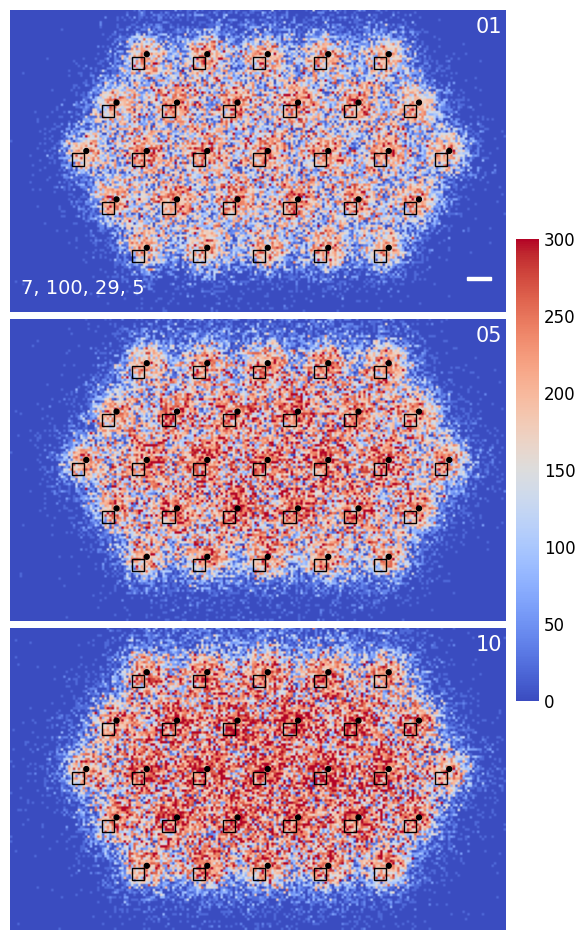

In [9]:
xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]
ssize = 0.02 # um
th = 2
APs = [1,5,10]
for d in dirs[9:10]:
    caGridFiles = [a for a in os.listdir(os.path.join(resultPath, simType, d)) 
                   if 'caGrid' in a and f'step_{ssize:0.2f}' in a]
    caGridFiles.sort(key=natural_keys)
    caGridFiles = np.array(caGridFiles)
    #print(d,caGridFiles)
    
    nAP = len(caGridFiles)-1
    
    # AZ grid
    xyaz, xyvdcc = getAZgrid(d, ssize, plot=False)
    azsize = 0.1
    #print(xyAZ)
    
    f, ax = plt.subplots(len(APs), figsize=(8,12), sharex=True, sharey=True)
    f.subplots_adjust(wspace=0.0, hspace=0.01)

    
    for i, caGridFile in enumerate(caGridFiles[APs]):
        with open(os.path.join(resultPath, simType, d, caGridFile), 'rb') as infile:
            cagrid = pk.load(infile, encoding="bytes")

        grid = np.sum(np.array(list(cagrid.values())), axis=0)
        gridth = np.argmax(grid<th, axis=2)*ssize*1000
        
        ax[i].axis('off')
        im = ax[i].imshow(gridth.T, vmin=0, vmax=300, cmap='coolwarm')
        
        for xy in xyaz: # Active Zones
            ax[i].add_patch(patches.Rectangle(xy, azsize/ssize, azsize/ssize,
                                              edgecolor='black', lw=1, fill=False))
            
        for xy in xyvdcc: # VDCC Cluster
            ax[i].add_patch(patches.Circle(xy, 0.02/ssize, edgecolor=cpdark[-1],
                                           facecolor=cpdark[-1], fill=True))
        
        #ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
        ax[i].invert_yaxis()
        ax[i].text(192, 115, f'{APs[i]:02d}', color='w', fontsize=15)
    
    label = str([int(a) for a in re.findall(r'\d+', d)[:-2]])[1:-1]
    ax[0].text(4, 7, label, color='w', fontsize=14)
    scalebar = AnchoredSizeBar(ax[0].transData,
                           10, '', 'lower right', 
                           pad=1,
                           color='white',
                           frameon=False,
                           size_vertical=1)

    ax[0].add_artist(scalebar)
        
    cb = f.colorbar(im, ax=ax.ravel().tolist(), shrink=0.5, anchor=(-0.3,0.5))
    cb.outline.set_visible(False)
    cb.ax.tick_params(size=0, labelsize=12)
    
    # f.savefig(os.path.join(figPath, f'Ca_{d}_____.eps'), fmt='eps', 
    #           dpi=100, bbox_inches='tight', transparent=True)

## Calcium binding capacity

In [10]:
xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]
ssize = 0.02 # um
th = 25 # % decrease in available calcium binding cites
APs = [1,5,10]
APs = [2,3,4]
for d in dirs[9:10]:
    cbGridFiles = [a for a in os.listdir(os.path.join(resultPath, simType, d)) 
                   if 'cbGrid' in a and f'step_{ssize:0.2f}' in a]
    cbGridFiles.sort(key=natural_keys)
    cbGridFiles = np.array(cbGridFiles)
    #print(cbGridFiles)
    
    nAP = len(cbGridFiles)
    
    # AZ grid
    xyaz, xyvdcc = getAZgrid(d, ssize, plot=False)
    azsize = 0.1
    #print(xyAZ)
    
    f, ax = plt.subplots(len(APs), figsize=(8,12), sharex=True, sharey=True)
    f.subplots_adjust(wspace=0.0, hspace=0.01)
    with open(os.path.join(resultPath, simType, d, cbGridFiles[0]), 'rb') as infile:
        cbgrid0 = pk.load(infile, encoding="bytes")
        cbc0 = 2*(cbgrid0[b'M0'] + cbgrid0[b'H0']) + cbgrid0[b'M1'] + cbgrid0[b'H1']
            
    for i, cbGridFile in enumerate(cbGridFiles[APs]):
        with open(os.path.join(resultPath, simType, d, cbGridFile), 'rb') as infile:
            cbgrid = pk.load(infile, encoding="bytes")
            cbc = 2*(cbgrid[b'M0'] + cbgrid[b'H0']) + cbgrid[b'M1'] + cbgrid[b'H1']
            cbc = (cbc0 - cbc)/cbc0*100

        gridth = np.argmin(cbc>th, axis=2)*ssize*1000
        
        ax[i].axis('off')
        im = ax[i].imshow(gridth.T, vmin=0, vmax=400, cmap='coolwarm')
        
        for xy in xyaz: # Active Zones
            ax[i].add_patch(patches.Rectangle(xy, azsize/ssize, azsize/ssize, 
                                              edgecolor='w', lw=1, fill=False))
            
        for xy in xyvdcc: # VDCC Cluster
            ax[i].add_patch(patches.Circle(xy, 0.02/ssize, edgecolor=cpdark[-1], 
                                           facecolor=cpdark[-1], fill=True))
        
        ax[i].invert_yaxis()
        ax[i].text(192, 115, f'{APs[i]:02d}', color='w', fontsize=15)
    
    ax[0].text(4, 7, str([int(a) for a in re.findall(r'\d+', d)[:-2]])[1:-1], 
               color='w', fontsize=14)
    scalebar = AnchoredSizeBar(ax[0].transData,
                           10, '', 'lower right', 
                           pad=1,
                           color='white',
                           frameon=False,
                           size_vertical=1)

    ax[0].add_artist(scalebar)
        
    cb = f.colorbar(im, ax=ax.ravel().tolist(), shrink=0.5, anchor=(-0.3,0.5))
    cb.outline.set_visible(False)
    cb.ax.tick_params(size=0, labelsize=12)
    
    f.savefig(os.path.join(figPath, f'Cb_{d}_dsfgdsfg.eps'), fmt='eps',
              dpi=100, bbox_inches = 'tight', transparent=True)

/tmp/ipykernel_1108884/597422849.py:63: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "fmt" which is no longer supported as of 3.3 and will become an error in 3.6
  f.savefig(os.path.join(figPath, f'Cb_{d}_dsfgdsfg.eps'), fmt='eps',


## Calcium and buffer together

In [10]:
xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]
ssize = 0.02 # um
thCa = 2 # calcium conc. (uM)
thCb = 20 # % decrease in available calcium binding cites
APs = [1,5,10]
sh = 400 # surface height
for d in dirs[:]:
    ## caGrid Data
    caGridFiles = [a for a in os.listdir(os.path.join(resultPath, simType, d)) 
                   if 'caGrid' in a and f'step_{ssize:0.2f}' in a]
    caGridFiles.sort(key=natural_keys)
    caGridFiles = np.array(caGridFiles)
    #print(d,caGridFiles)

    ## cbGrid Data
    cbGridFiles = [a for a in os.listdir(os.path.join(resultPath, simType, d)) 
                   if 'cbGrid' in a and f'step_{ssize:0.2f}' in a]
    cbGridFiles.sort(key=natural_keys)
    cbGridFiles = np.array(cbGridFiles)
    with open(os.path.join(resultPath, simType, d, cbGridFiles[0]), 'rb') as infile:
        cbgrid0 = pk.load(infile, encoding="bytes")
        cbc0 = 2*(cbgrid0[b'M0'] + cbgrid0[b'H0']) + cbgrid0[b'M1'] + cbgrid0[b'H1']
    #print(cbGridFiles)
    
    nAP = len(caGridFiles)-1
    
    ## AZ grid
    xyaz, xyvdcc = getAZgrid(d, ssize, plot=False)
    azsize = 0.1
    #print(xyAZ)
    
    f, ax = plt.subplots(2, len(APs), figsize=(16,5.38), sharex=True, sharey=True)
    f.subplots_adjust(wspace=0.01, hspace=0.005)
    for i, (caGridFile, cbGridFile) in enumerate(list(zip(caGridFiles[APs], cbGridFiles[APs]))):
        ## ca plot
        with open(os.path.join(resultPath, simType, d, caGridFile), 'rb') as infile:
            cagrid = pk.load(infile, encoding="bytes")

        grid = np.sum(np.array(list(cagrid.values())), axis=0)
        gridth = np.argmax(grid<thCa, axis=2)*ssize*1000
        
        ax[0,i].axis('off')
        imCa = ax[0,i].imshow(gridth.T, vmin=0, vmax=sh, cmap='coolwarm')
        
        for xy in xyaz: # Active Zones
            ax[0,i].add_patch(patches.Rectangle(xy, azsize/ssize, azsize/ssize, lw=0,
                                                facecolor=cpdark[-1], fill=True))
            
        for xy in xyvdcc: # VDCC Cluster
            ax[0,i].add_patch(patches.Circle(xy, 0.02/ssize, edgecolor=cpdark[-1], 
                                             facecolor=cpdark[-1], fill=True))
        
        #ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
        ax[0,i].invert_yaxis()
        ax[0,i].text(185, 110, f'{APs[i]:02d}', color='w', fontsize=12)
        
        ## cb plot
        with open(os.path.join(resultPath, simType, d, cbGridFile), 'rb') as infile:
            cbgrid = pk.load(infile, encoding="bytes")
            cbc = 2*(cbgrid[b'M0'] + cbgrid[b'H0']) + cbgrid[b'M1'] + cbgrid[b'H1']
            cbc = (cbc0 - cbc)/cbc0*100

        gridth = np.argmin(cbc>thCb, axis=2)*ssize*1000
        
        ax[1,i].axis('off')
        imCb = ax[1,i].imshow(gridth.T, vmin=0, vmax=sh, cmap='coolwarm')
        
        for xy in xyaz: # Active Zones
            ax[1,i].add_patch(patches.Rectangle(xy, azsize/ssize, azsize/ssize, lw=0,
                                                facecolor=cpdark[-1], fill=True))
            
        for xy in xyvdcc: # VDCC Cluster
            ax[1,i].add_patch(patches.Circle(xy, 0.02/ssize, edgecolor=cpdark[-1], 
                                             facecolor=cpdark[-1], fill=True))
        
        ax[1,i].invert_yaxis()
        ax[1,i].text(185, 110, f'{APs[i]:02d}', color='w', fontsize=12)
    
    label = str([int(a) for a in re.findall(r'\d+', d)[:-2]])[1:-1]
    ax[1,0].text(2, 4, label, color='w', fontsize=12)
    ax[0,0].text(4, 110, 'calcium', color='w', fontsize=12)
    ax[1,0].text(4, 110, 'calbindin', color='w', fontsize=12)
    ax[0,0].text(4, 60, 'a', color='w', fontsize=20)
    ax[1,0].text(4, 60, 'b', color='w', fontsize=20)
    scalebar = AnchoredSizeBar(ax[0,0].transData,
                           25, '500nm', 'lower left', 
                           pad=1,
                           color='white',
                           frameon=False,
                           size_vertical=1)

    ax[0,0].add_artist(scalebar)
     
    ## Ca colorbar
    cb = f.colorbar(imCa, ax=ax.ravel().tolist(), shrink=0.6, anchor=(-0.3,0.5))
    cb.outline.set_visible(False)
    cb.ax.tick_params(size=0, labelsize=8)
    
    f.savefig(os.path.join(figPath, f'{d}.eps'), fmt='eps',
              dpi=100, bbox_inches='tight', transparent=True);

/home/nishant/.local/lib/python3.6/site-packages/ipykernel_launcher.py:32: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
